In [25]:
import torch

# ตรวจสอบและใช้งาน GPU ของชิป M4
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"รันโมเดลบน: {device}")

รันโมเดลบน: mps


In [26]:
import numpy as np
from scipy.io import loadmat

ai_model = 'cnn'
snr = 0
scenario = 'O1'
frequency = 60
antennas = 64

path = f'../DeepMIMO/DeepMIMO/DeepMIMO_dataset/SNR{snr}dB_{scenario}_{frequency}_Ant{antennas}/'
d1 = loadmat(path+'channel1.mat')['a']
d2 = loadmat(path+'channel2.mat')['b']
d3 = loadmat(path+'channel3.mat')['c']

data = np.concatenate((d1, d2, d3), axis=2).transpose(2, 0, 1)

d_r = data.real.reshape(-1, 1, 64, 32)
d_i = data.imag.reshape(-1, 1, 64, 32)

X = np.concatenate((d_r, d_i), axis=1)
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - mean) / (std + 1e-8) # 1e-8 prevents division by zero

print("Data normalization complete. Features now have Mean ≈ 0 and Std ≈ 1.")

# Load Label (One-hot encoding)
y = loadmat(path+'DLCB_output.mat')['onehot_label']

print(f"Input shape: {X.shape}")
print(f"Label shape: {y.shape}")

Data normalization complete. Features now have Mean ≈ 0 and Std ≈ 1.
Input shape: (53467, 2, 64, 32)
Label shape: (53467, 64)


In [27]:
from torch.utils.data import DataLoader, TensorDataset

split_idx = int(len(X) * 0.7)

# Training set: The first 70% of the user path
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Data Split Complete:")
print(f" - Training samples: {len(X_train)} (First 70%)")
print(f" - Testing samples:  {len(X_test)} (Last 30% - Future Path)")

train_ds = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float())
test_ds = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).float())

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

Data Split Complete:
 - Training samples: 37426 (First 70%)
 - Testing samples:  16041 (Last 30% - Future Path)


In [28]:
import torch
import torch.nn as nn
import numpy as np
import random

def apply_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
        
    print(f"Global environment locked with seed: {seed}")

apply_global_seed(42)

class BeamPredictionCNN(nn.Module):
    def __init__(self, n_beams, dropout_rate=0.2):
        super(BeamPredictionCNN, self).__init__()
        
        # ส่วนสกัดฟีเจอร์ (Conv Layers)
        self.cnn = nn.Sequential(
            # Conv Layer 1: รับ 2 channels, ส่งออก 16 channels, kernel 3x3
            nn.Conv2d(in_channels=2, out_channels=16, kernel_size=3, padding=1, bias=False),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Conv Layer 2: รับ 16 channels, ส่งออก 48 channels
            nn.Conv2d(in_channels=16, out_channels=48, kernel_size=3, padding=1, bias=False),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4),
            nn.Dropout(dropout_rate)
        )
        
        # Fully Connected Layers
        self.linear = nn.Sequential(
            nn.Linear(6144, 511),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(511, n_beams)
        )

    def forward(self, x):
        x = self.cnn(x) # สกัดฟีเจอร์ด้วย CNN
        x = x.view(x.size(0), -1) # Flatten ข้อมูลเพื่อเข้า Linear layer
        x = self.linear(x) # ทำนายผล
        return x

Global environment locked with seed: 42


In [29]:
model = BeamPredictionCNN(n_beams=64, dropout_rate=0.2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss()

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total Trainable Params: {params}')

Total Trainable Params: 3180063


In [ ]:
epochs = 100
best_loss = float('inf')
train_losses = []

for epoch in range(epochs):
    epoch_loss = 0.0
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        # Use torch.max to find the best index of beam for CrossEntropyLoss
        loss = criterion(outputs, torch.max(labels, 1)[1])
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)
        
    scheduler.step(avg_epoch_loss)
        
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Avg Loss: {avg_epoch_loss:.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        torch.save(model.state_dict(), f'best_{ai_model}_model.pth')
        print(f"--> Saved better model at Epoch {epoch+1} with Loss: {best_loss:.4f}")

        

--> Saved better model at Epoch 1 with Loss: 1.4132
--> Saved better model at Epoch 2 with Loss: 0.6054
--> Saved better model at Epoch 3 with Loss: 0.4889
--> Saved better model at Epoch 4 with Loss: 0.4430
--> Saved better model at Epoch 5 with Loss: 0.3963
--> Saved better model at Epoch 6 with Loss: 0.3762
--> Saved better model at Epoch 7 with Loss: 0.3337
--> Saved better model at Epoch 8 with Loss: 0.3243
--> Saved better model at Epoch 9 with Loss: 0.3022
Epoch [10/100], Avg Loss: 0.2901, LR: 0.001000
--> Saved better model at Epoch 10 with Loss: 0.2901
--> Saved better model at Epoch 11 with Loss: 0.2744
--> Saved better model at Epoch 12 with Loss: 0.2651
--> Saved better model at Epoch 13 with Loss: 0.2392
--> Saved better model at Epoch 14 with Loss: 0.2332
--> Saved better model at Epoch 15 with Loss: 0.2251
--> Saved better model at Epoch 16 with Loss: 0.2195
--> Saved better model at Epoch 17 with Loss: 0.2005
--> Saved better model at Epoch 18 with Loss: 0.1987
--> Save

In [31]:
model.load_state_dict(torch.load(f'best_{ai_model}_model.pth'))
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        _, actual = torch.max(labels.data, 1)
        total += labels.size(0)
        correct += (predicted == actual).sum().item()
        
print(f'Average Accuracy on SNR 0dB: {100 * correct / total:.2f}%')

Average Accuracy on SNR 0dB: 96.40%


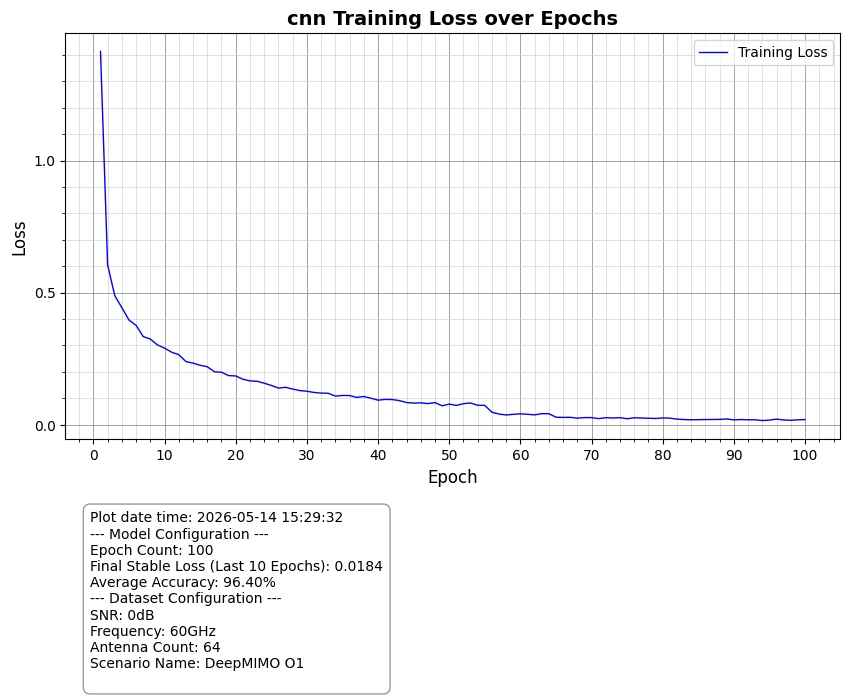

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime

initial_datetime = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
final_avg_loss = np.mean(train_losses[-10:])

plt.figure(figsize=(10, 7)) # Increased height slightly for the text
plt.plot(range(1, epochs + 1), train_losses, color='blue', label='Training Loss', linewidth=1)

# Graph styling
plt.title(f'{ai_model} Training Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
# Enable minor ticks
plt.minorticks_on()

# Configure Major Grid (the darker, main lines)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='gray', alpha=1)

# Configure Minor Grid (the lighter, more frequent lines)
plt.grid(which='minor', linestyle='-', linewidth='0.5', color='lightgray', alpha=1)

# Optional: Set specific frequency for ticks
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(2))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.5))
plt.gca().yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
plt.legend()

# 2. Add extra space at the bottom for the configuration text
plt.subplots_adjust(bottom=0.3)

# 3. Construct the configuration string
config_text = (
    f"Plot date time: {initial_datetime}\n"
    f"--- Model Configuration ---\n"
    f"Epoch Count: {epochs}\n"
    f"Final Stable Loss (Last 10 Epochs): {final_avg_loss:.4f}\n"
    f"Average Accuracy: {100 * correct / total:.2f}%\n"
    f"--- Dataset Configuration ---\n"
    f"SNR: {snr}dB\n"
    f"Frequency: {frequency}GHz\n"
    f"Antenna Count: {antennas}\n"
    f"Scenario Name: DeepMIMO {scenario}\n"
)

# 4. Place the text in the blank space
plt.figtext(0.15, -0.05, config_text, 
            fontsize=10, 
            ha="left", 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))



plt.show()

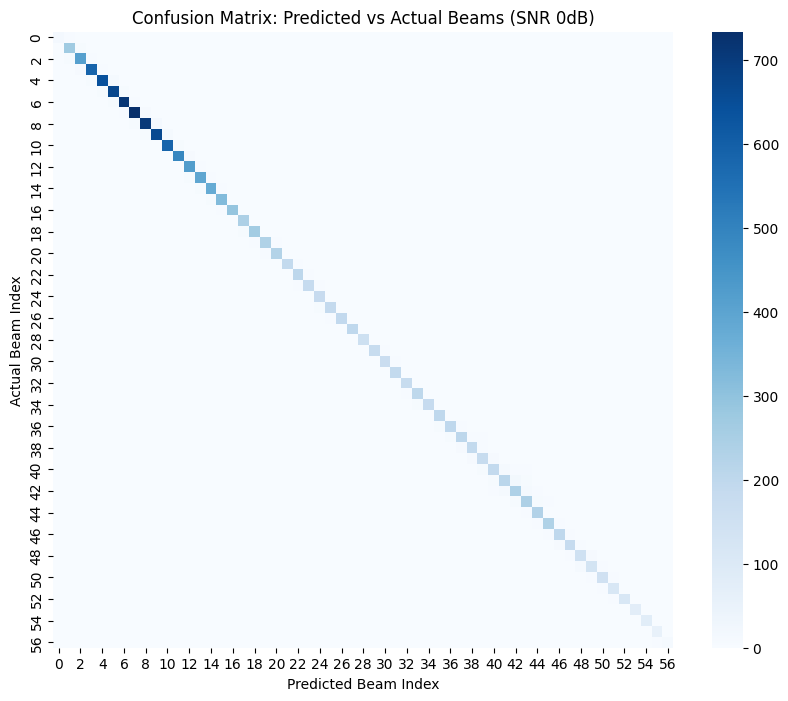

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# เก็บค่าผลลัพธ์ทั้งหมด
all_preds = []
all_actuals = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        _, actual = torch.max(labels, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_actuals.extend(actual.cpu().numpy())

# สร้าง Confusion Matrix
cm = confusion_matrix(all_actuals, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual Beams (SNR 0dB)')
plt.xlabel('Predicted Beam Index')
plt.ylabel('Actual Beam Index')
plt.show()

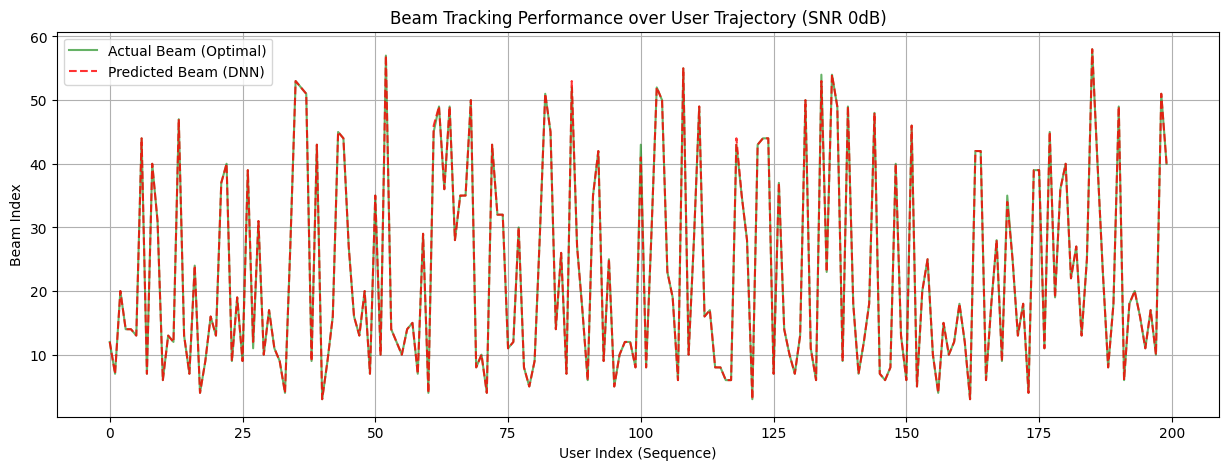

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(all_actuals[:200], 'g-', label='Actual Beam (Optimal)', alpha=0.6)
plt.plot(all_preds[:200], 'r--', label='Predicted Beam (DNN)', alpha=0.8)
plt.title('Beam Tracking Performance over User Trajectory (SNR 0dB)')
plt.xlabel('User Index (Sequence)')
plt.ylabel('Beam Index')
plt.legend()
plt.grid(True)
plt.show()